In [1]:
# Get daily constraint ranked by the abs RT - DA 
from functions import (
    get_recent_constraint_mvalue,
    get_node_dfax_from_constraint_num,
    get_hourly_mvalue_for_constraint_num,
    get_constraint_node_prices_from_constraint_num,
    get_constraints_node_price,
    get_metrics_for_nodes,
    get_recent_direction_accuracy,
    get_weather_date,
    predict_tomorrow_percentile,
    analyze_constraint_by_zone,
    plot_constraint_seasonality,
    plot_recent_hourly_distribution,
)
import pandas as pd

In [2]:
now = pd.Timestamp.now(tz='US/Central')
days_ahead = 2 if now.hour >= 10 else 1
bid_dt = (now + pd.Timedelta(days=days_ahead)).strftime('%Y-%m-%d')
print(bid_dt)

2026-06-09


In [9]:
dt = (pd.Timestamp(bid_dt) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
mvalue= get_recent_constraint_mvalue(dt, dt)
dfax= get_node_dfax_from_constraint_num(mvalue)
hourly_mvalue = get_hourly_mvalue_for_constraint_num(mvalue)
fundamentals = get_weather_date(hourly_mvalue, dt)

start_dt: 2026-06-07, end_dt: 2026-06-07, Market: SPP
Fetching RT mvalues...
Fetching DA mvalues...
RT constraints: 0, DA constraints: 61
Fetching constraint details...


,oops_constraint_num,rt_total,da_total,rt_da,abs_rt_da_diff,monitored,contingency
0,877321,0,-1766.7767,1766.7767,1766.7767,lneeur-vaug_rev23,kcplwr:lacygnen345:345:1:10
1,842371,0,-1745.5446,1745.5446,1745.5446,lnfirstcrk-roanrdge,kcpl:nashuashale:345:1:11
2,776592,0,-1517.0713,1517.0713,1517.0713,xfmrduncan-duncan,wfec:anadarkofletch3comanch2:138
3,545011,0,-1059.9945,1059.9945,1059.9945,lnraun-tekamho,mecoppd:raunft_cal:345:2:10
11,880643,0,-400.2783,400.2783,400.2783,lneeur-vaug_rev23,wr:n345neordg:345:1:11
13,826289,0,-285.7601,285.7601,285.7601,xfmrduncan-duncan,okgecsws:sunnysdeterry_rd:345:2:


RT active constraint-days: 0
DA active constraint-days: 260
   oops_constraint_num          dt  hr  rt_mvalue  da_mvalue     rt_da
0               545011  2024-10-02   1          0  -325.6503  325.6503
1               545011  2024-10-02   2          0  -203.7223  203.7223
2               545011  2024-10-02   3          0  -105.4086  105.4086
3               545011  2024-10-02   4          0   -67.1355   67.1355
4               545011  2024-10-02   5          0   -30.9073   30.9073

Merged hourly rows: 2243


,oops_constraint_num,dt,hr,rt_mvalue,da_mvalue,rt_da,monitored,contingency
0,545011,2024-10-02,1,0,-325.6503,325.6503,lnraun-tekamho,mecoppd:raunft_cal:345:2:10
1,545011,2024-10-02,2,0,-203.7223,203.7223,lnraun-tekamho,mecoppd:raunft_cal:345:2:10
2,545011,2024-10-02,3,0,-105.4086,105.4086,lnraun-tekamho,mecoppd:raunft_cal:345:2:10
3,545011,2024-10-02,4,0,-67.1355,67.1355,lnraun-tekamho,mecoppd:raunft_cal:345:2:10
4,545011,2024-10-02,5,0,-30.9073,30.9073,lnraun-tekamho,mecoppd:raunft_cal:345:2:10
...,...,...,...,...,...,...,...,...
2238,877321,2026-05-07,5,0,-41.3961,41.3961,lneeur-vaug_rev23,kcplwr:lacygnen345:345:1:10
2239,877321,2026-05-07,6,0,-77.3266,77.3266,lneeur-vaug_rev23,kcplwr:lacygnen345:345:1:10
2240,880643,2026-05-19,4,0,-112.5029,112.5029,lneeur-vaug_rev23,wr:n345neordg:345:1:11
2241,880643,2026-05-19,5,0,-630.8573,630.8573,lneeur-vaug_rev23,wr:n345neordg:345:1:11


Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


monitored
lneeur-vaug_rev23         5
lnfirstcrk-roanrdge     266
lnraun-tekamho          570
xfmrduncan-duncan      1402


Constraint  : 'lneeur-vaug_rev23'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0003  |  Total hours: 14712


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lneeur-vaug_rev23,4,rz4_spp_res_zonal_wind_forecast_f,0.0003,0.0,-1.0
1,lneeur-vaug_rev23,4,rz4_spp_res_zonal_load_forecast_f,0.0003,0.0,-1.0


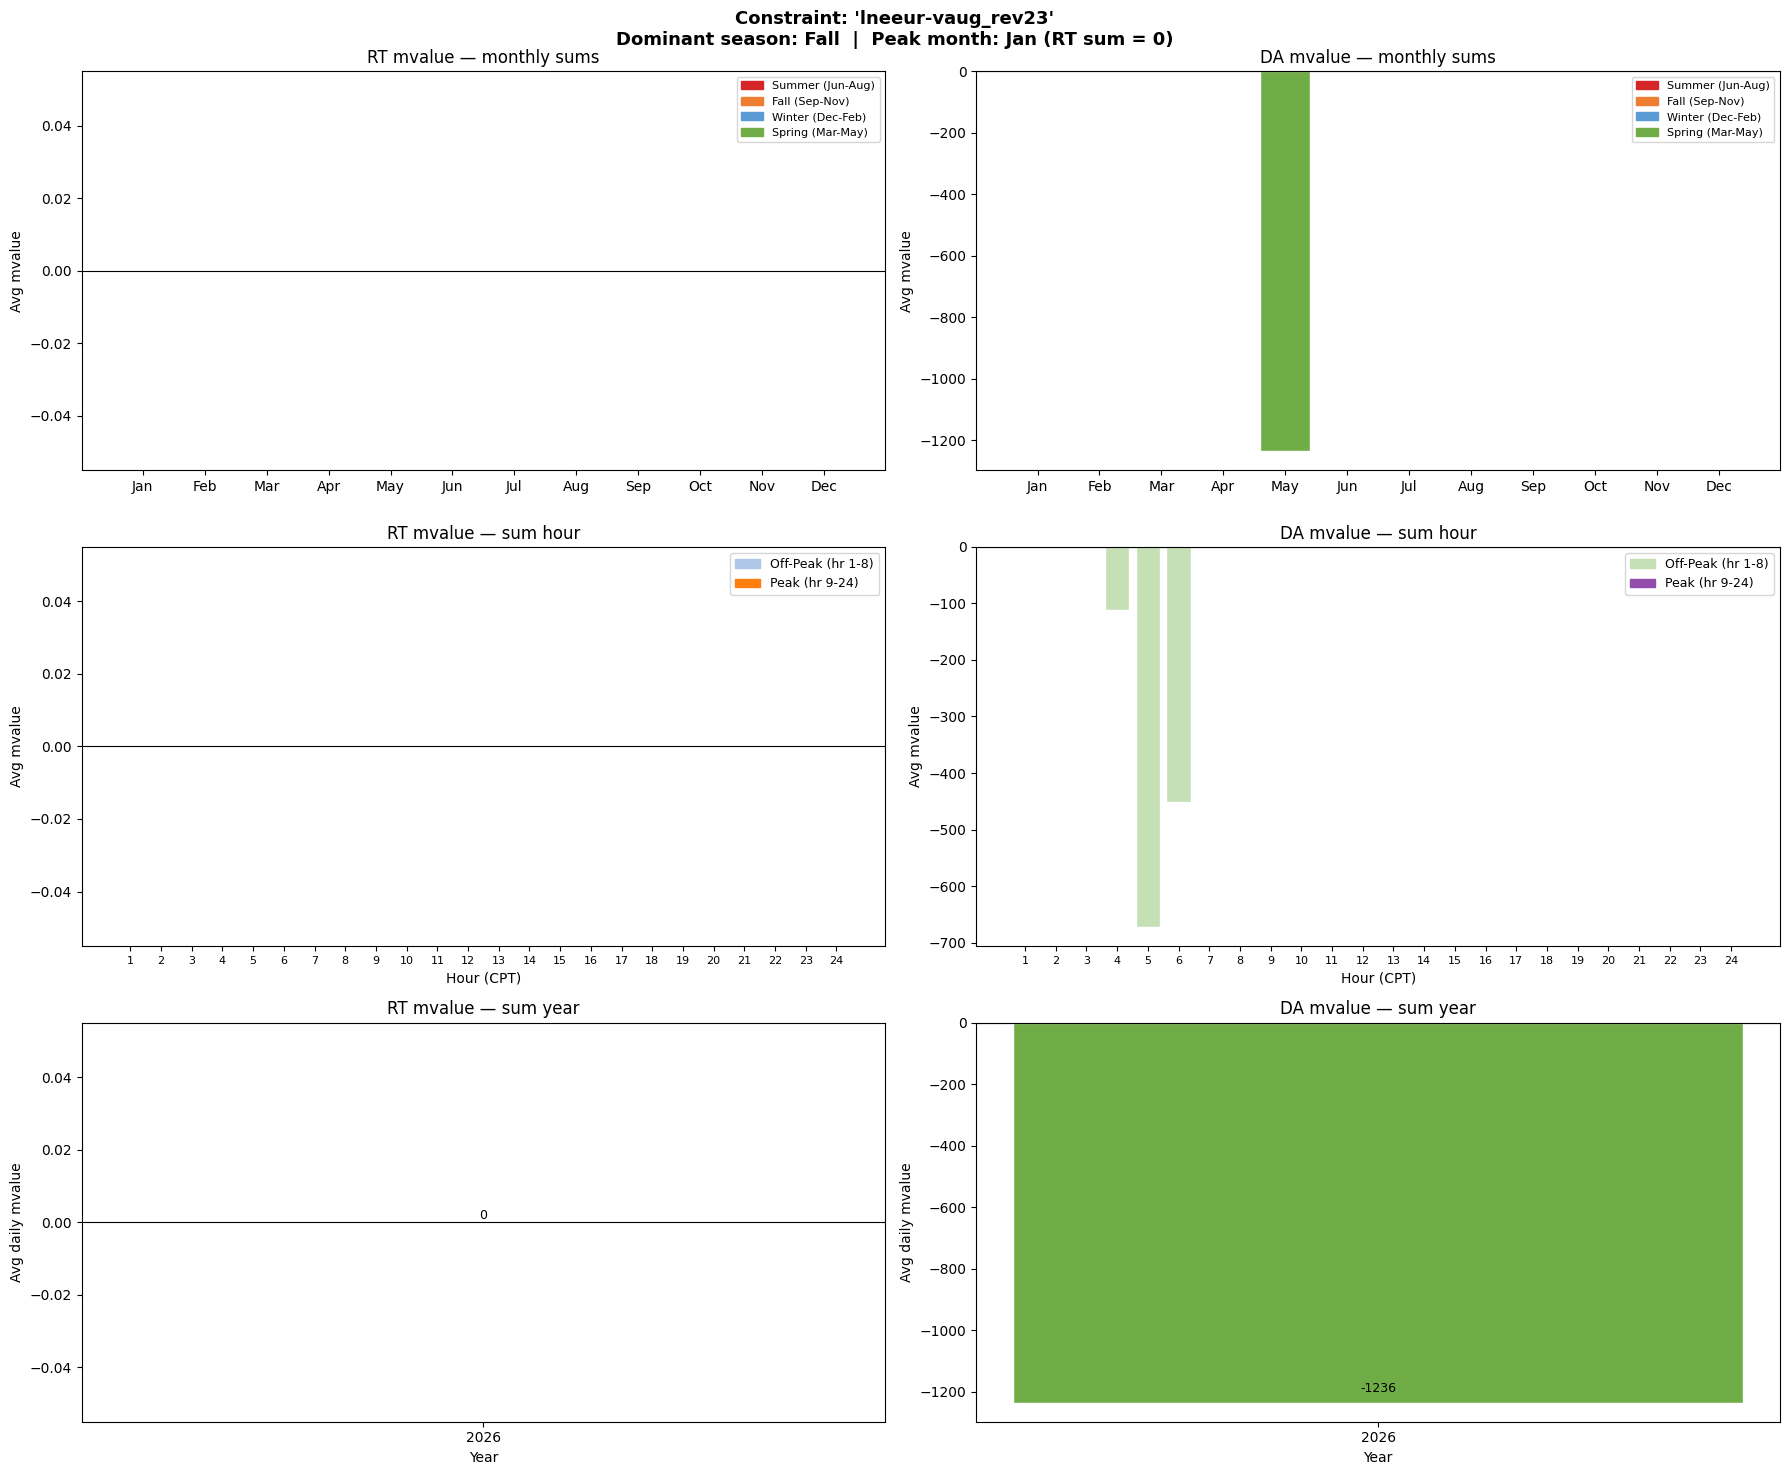

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):   -1236.31
No data for 'lneeur-vaug_rev23' between 2026-05-27 and 2026-06-06
lneeur-vaug_rev23 could not find the dfax value


Constraint  : 'lnfirstcrk-roanrdge'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0181  |  Total hours: 14712


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnfirstcrk-roanrdge,4,rz4_spp_res_zonal_wind_forecast_f,0.0181,0.0652,2.61
1,lnfirstcrk-roanrdge,4,rz4_spp_res_zonal_load_forecast_f,0.0181,0.0082,-0.55


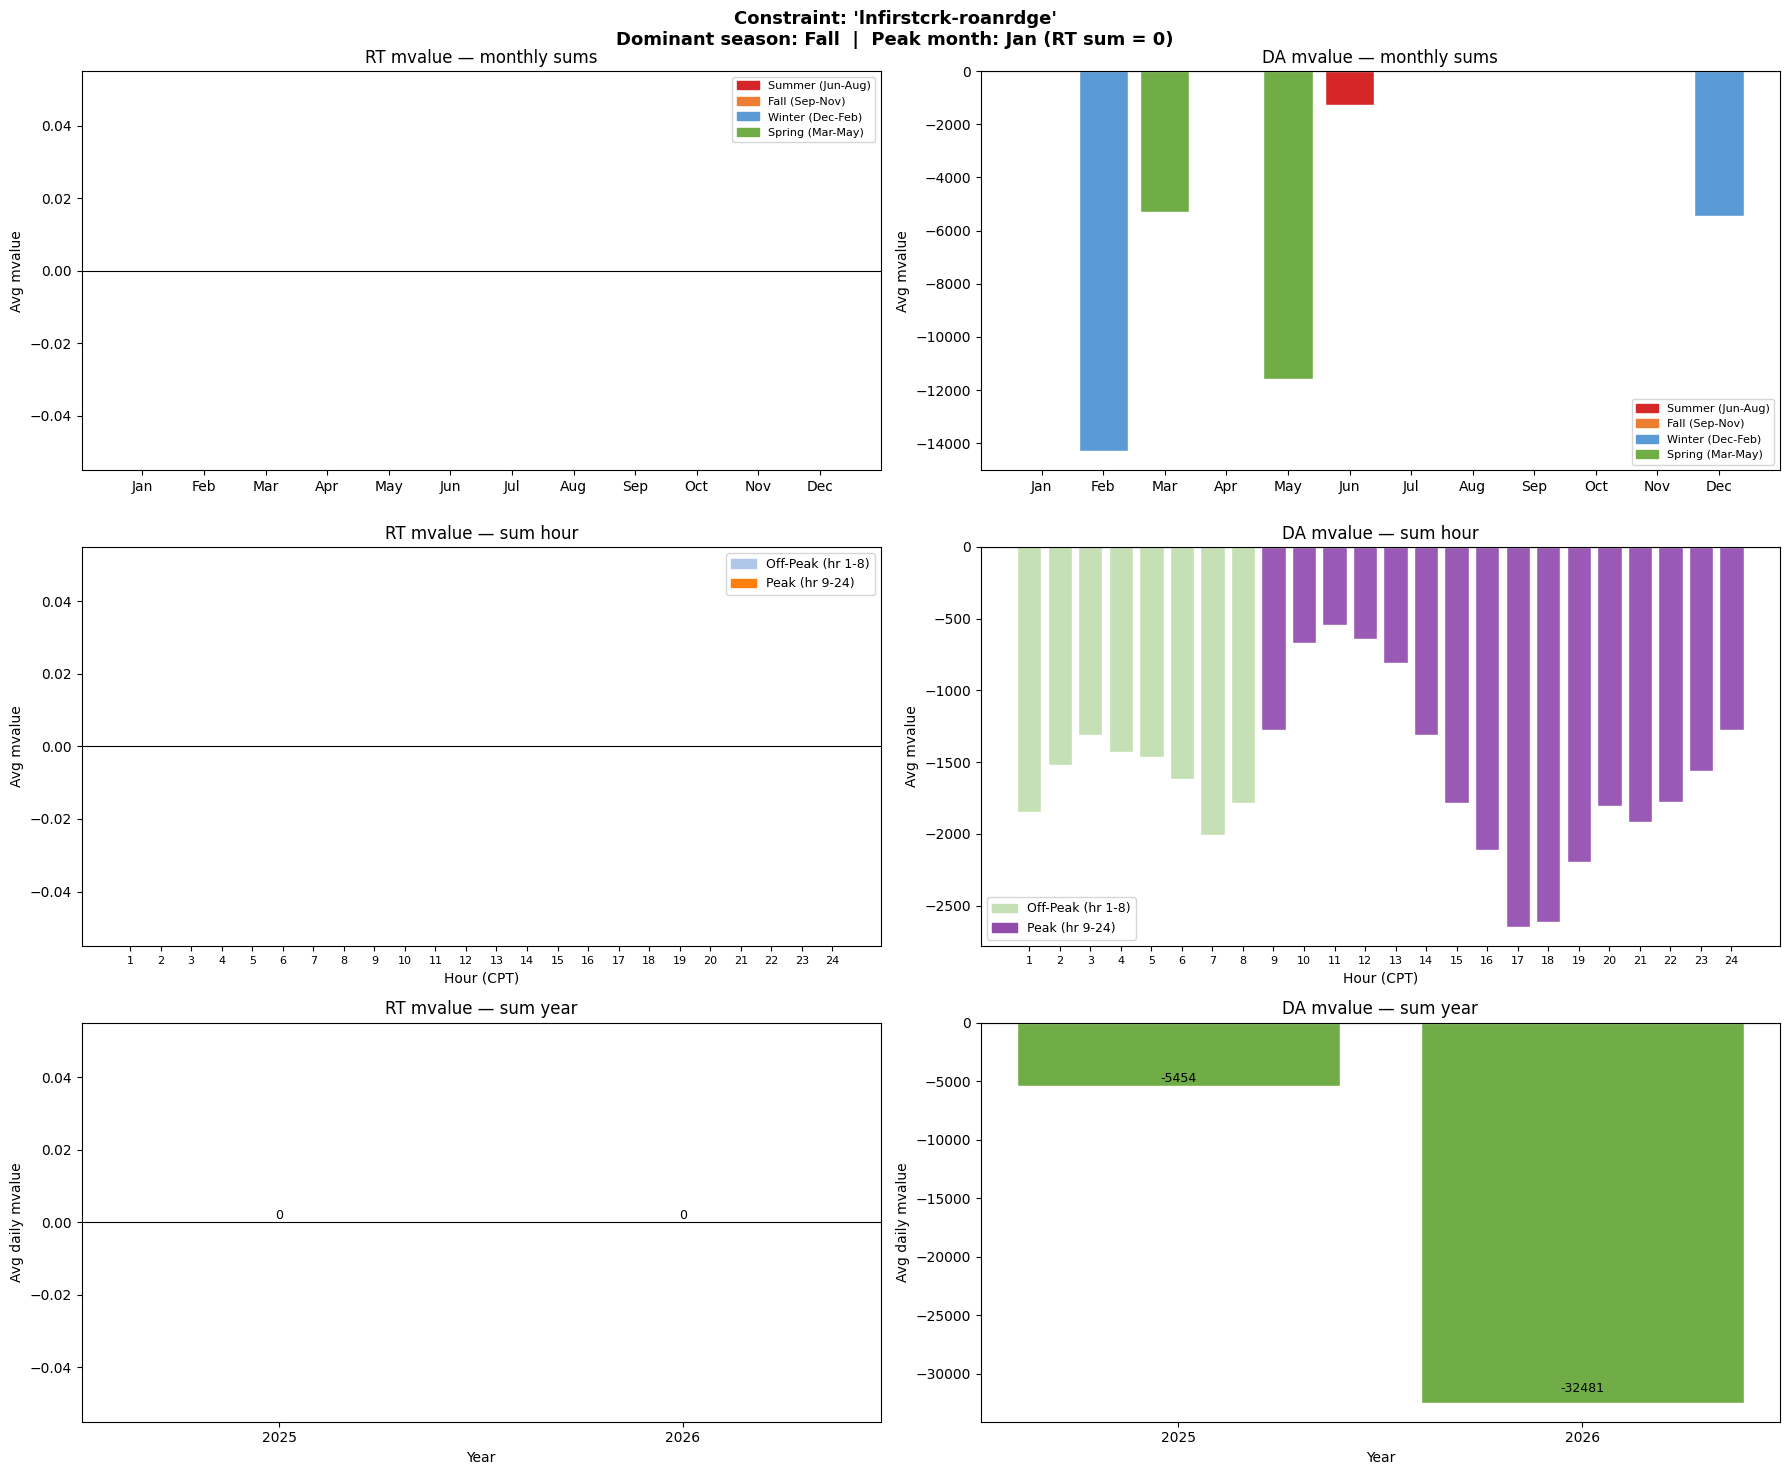

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -24963.34  |  off-peak (hr 1-8):  -12971.95
'lnfirstcrk-roanrdge'  |  2026-05-27 → 2026-06-06  |  6 days


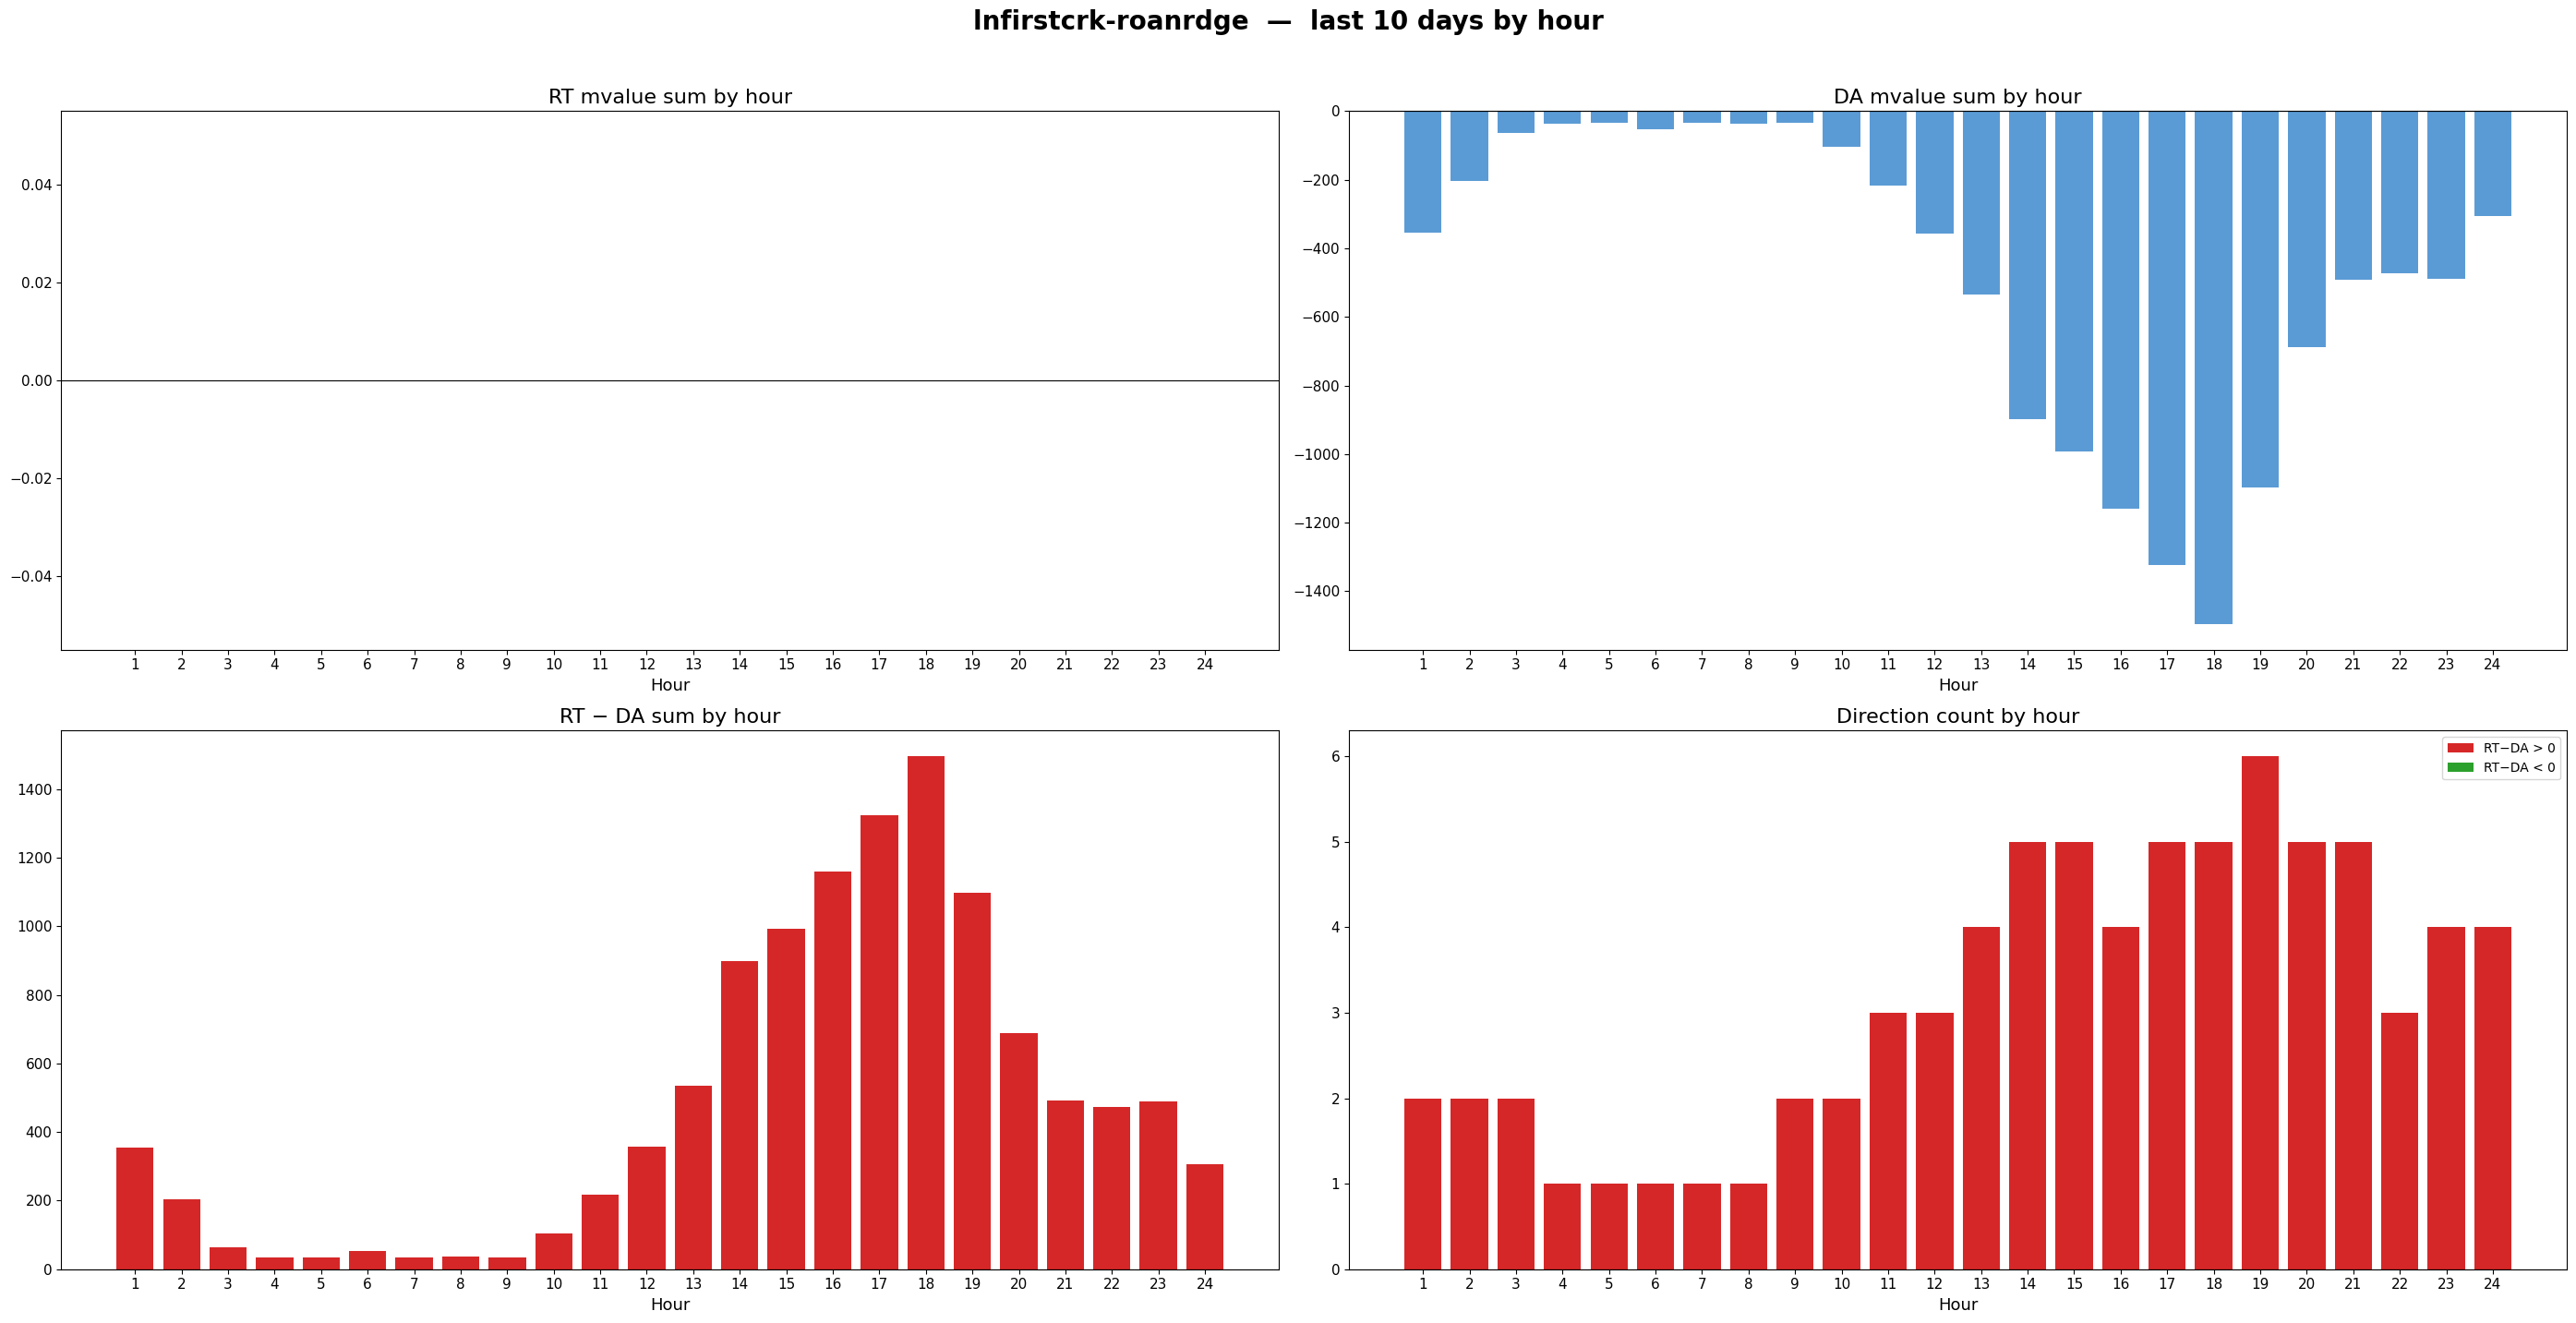


Total rows: 8246

  lnfirstcrk-roanrdge


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,233,0.1377,0.163476,0.700758,-19.728640,-0.949373,264.0
1,232,0.1223,0.159016,0.693182,-17.522241,-0.838910,264.0
2,237,0.1282,0.151539,0.689394,-18.367550,-0.397779,264.0
3,228,0.1392,0.143704,0.704545,-19.943549,-0.619471,264.0
4,230,0.1392,0.143703,0.704545,-19.943549,-0.619601,264.0
5,1671,0.0576,0.091919,0.666667,-8.252503,2.528278,264.0
6,274,0.0538,0.072032,0.617424,-7.708067,3.467460,264.0
7,263,0.0745,0.065626,0.662879,-10.673810,2.937763,264.0
8,262,0.0745,0.065626,0.662879,-10.673810,2.937757,264.0
9,266,0.0745,0.065620,0.662879,-10.673810,2.937349,264.0


Constraint  : 'lnraun-tekamho'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0387  |  Total hours: 14712


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnraun-tekamho,4,rz4_spp_res_zonal_wind_forecast_f,0.0387,0.0543,0.40
1,lnraun-tekamho,4,rz4_spp_res_zonal_load_forecast_f,0.0387,0.0367,-0.05


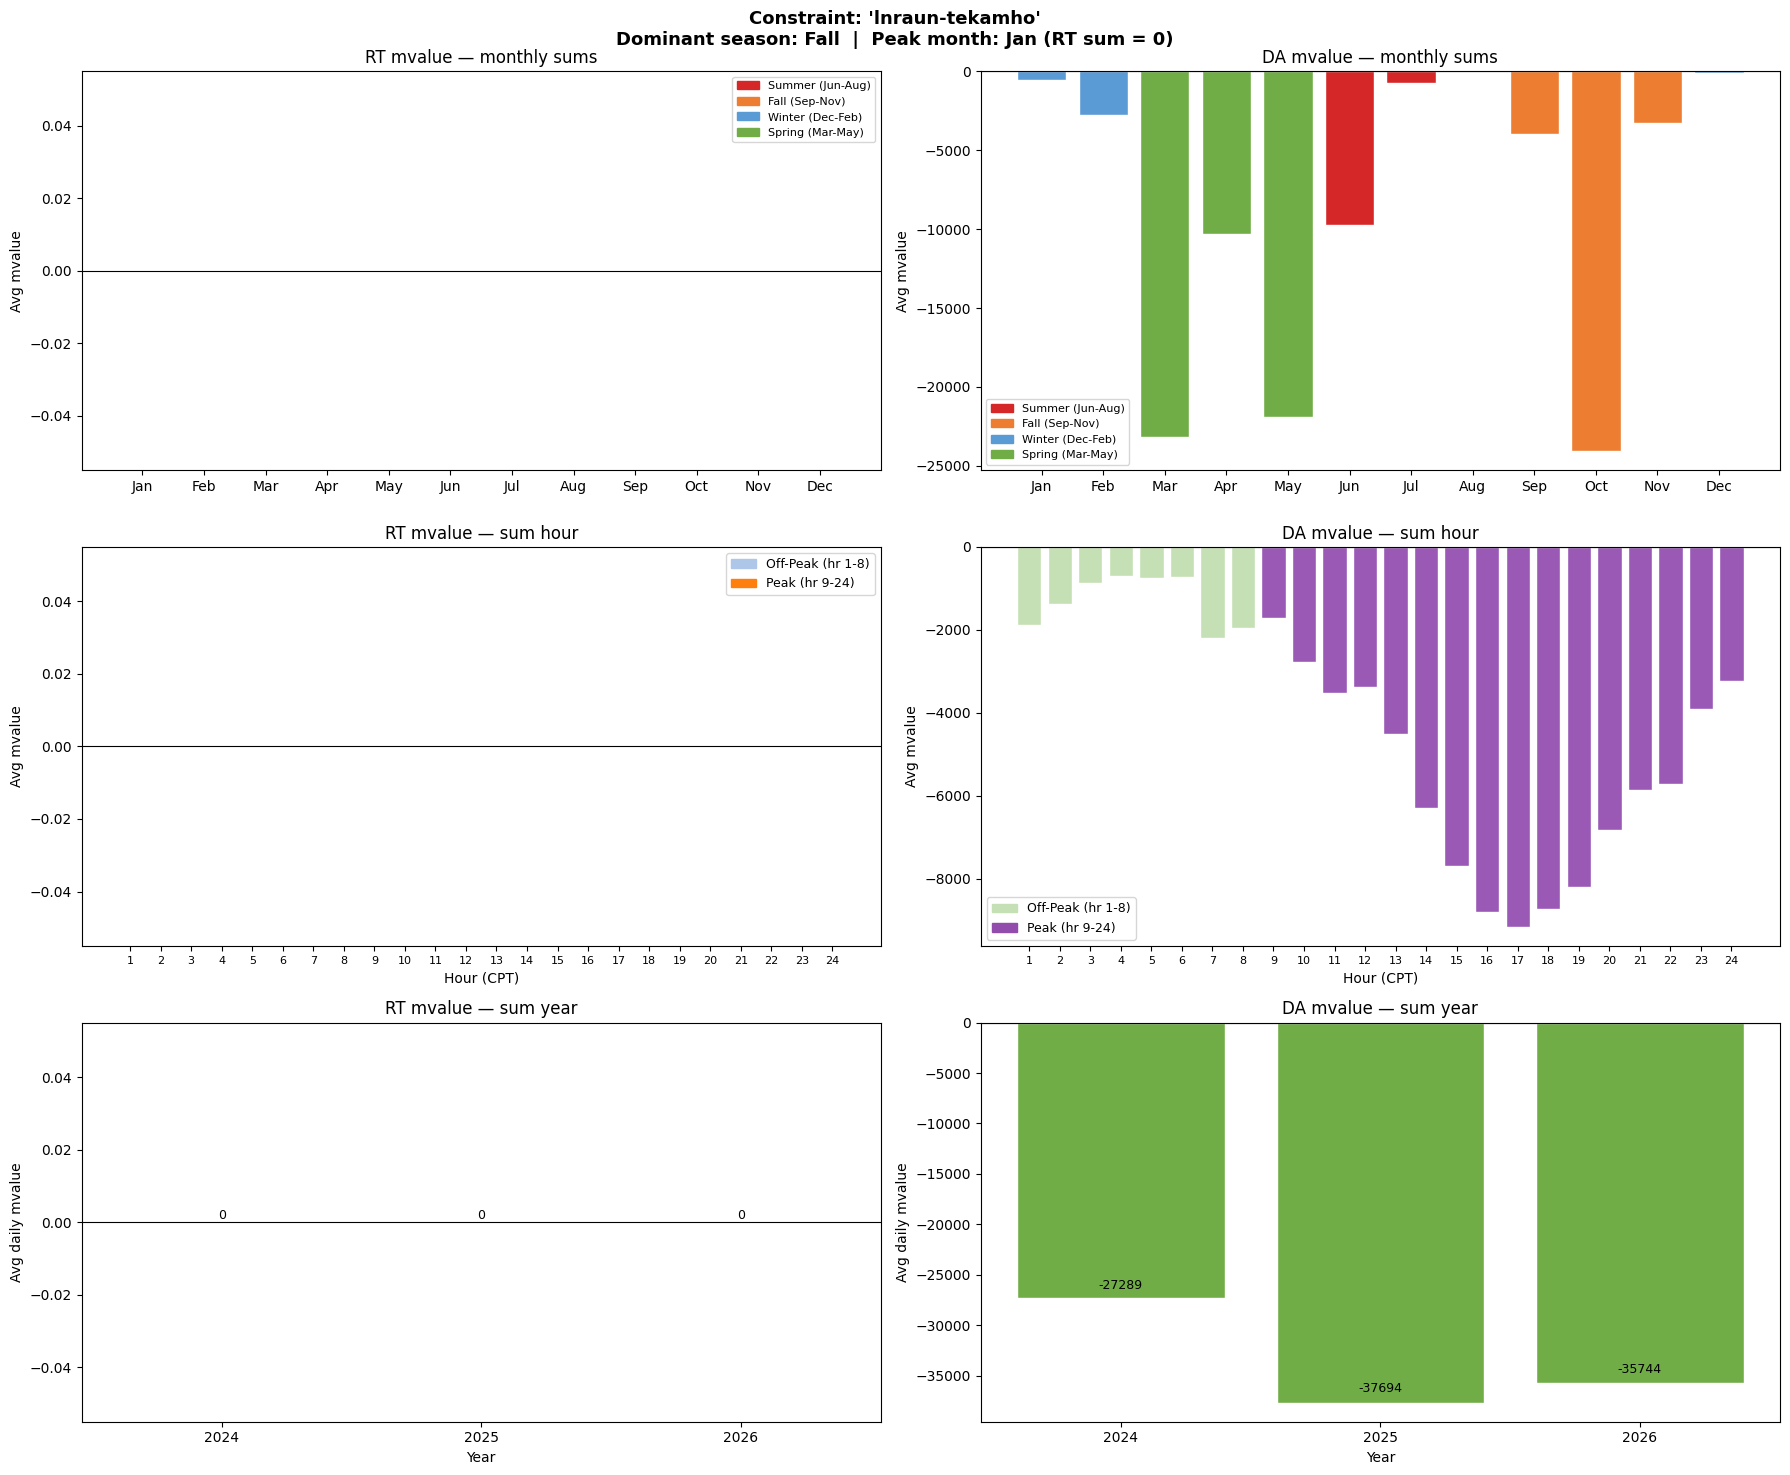

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -90281.35  |  off-peak (hr 1-8):  -10446.47
'lnraun-tekamho'  |  2026-05-27 → 2026-06-06  |  4 days


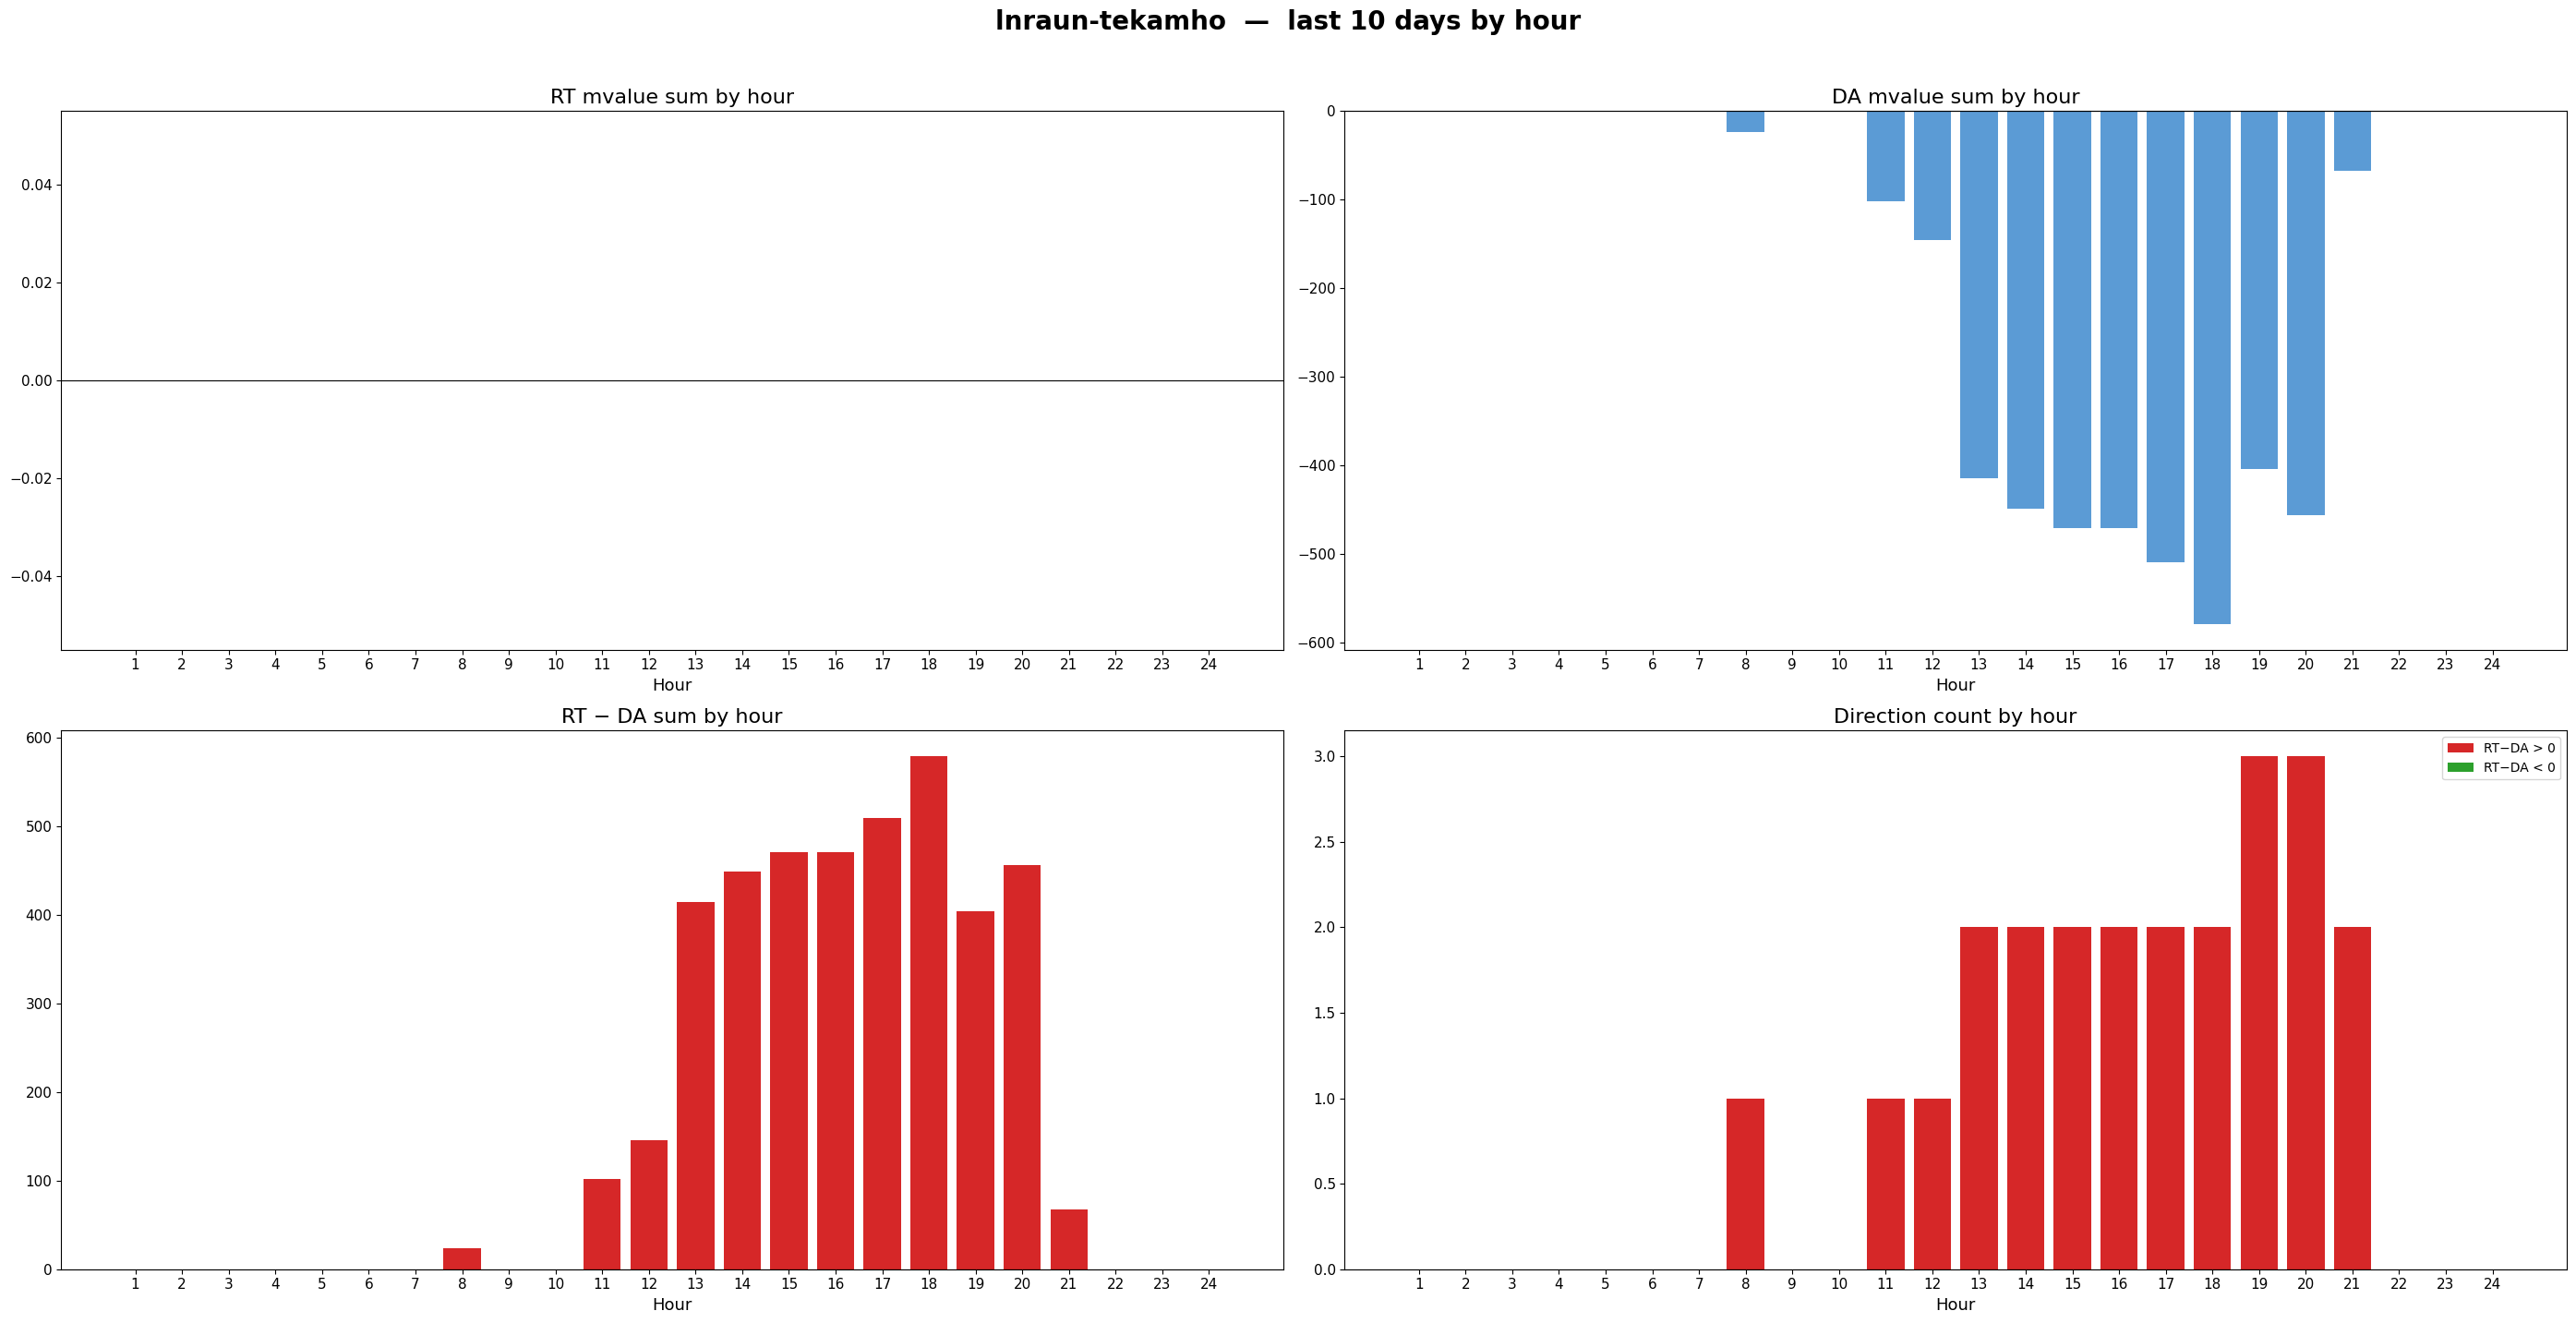


Total rows: 13110

  lnraun-tekamho


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,890,-0.0823,0.266859,0.507018,14.543683,5.272759,570.0
1,936,-0.0823,0.266859,0.507018,14.543683,5.272759,570.0
2,951,-0.0823,0.266859,0.507018,14.543683,5.272759,570.0
3,1456,-0.0582,0.202853,0.456140,10.284840,3.519656,570.0
4,1457,-0.0582,0.202853,0.456140,10.284840,3.519656,570.0
5,184,0.0882,0.151027,0.717544,-15.586304,-6.401150,570.0
6,182,0.0882,0.150164,0.717544,-15.586304,-6.374737,570.0
7,183,0.0882,0.150114,0.717544,-15.586304,-6.374557,570.0
8,185,0.0882,0.150012,0.717544,-15.586304,-6.355682,570.0
9,181,0.0877,0.149054,0.717544,-15.497947,-6.398730,570.0


Constraint  : 'xfmrduncan-duncan'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0952  |  Total hours: 14712


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,xfmrduncan-duncan,4,rz4_spp_res_zonal_wind_forecast_f,0.0952,0.2432,1.55
1,xfmrduncan-duncan,4,rz4_spp_res_zonal_load_forecast_f,0.0952,0.1345,0.41


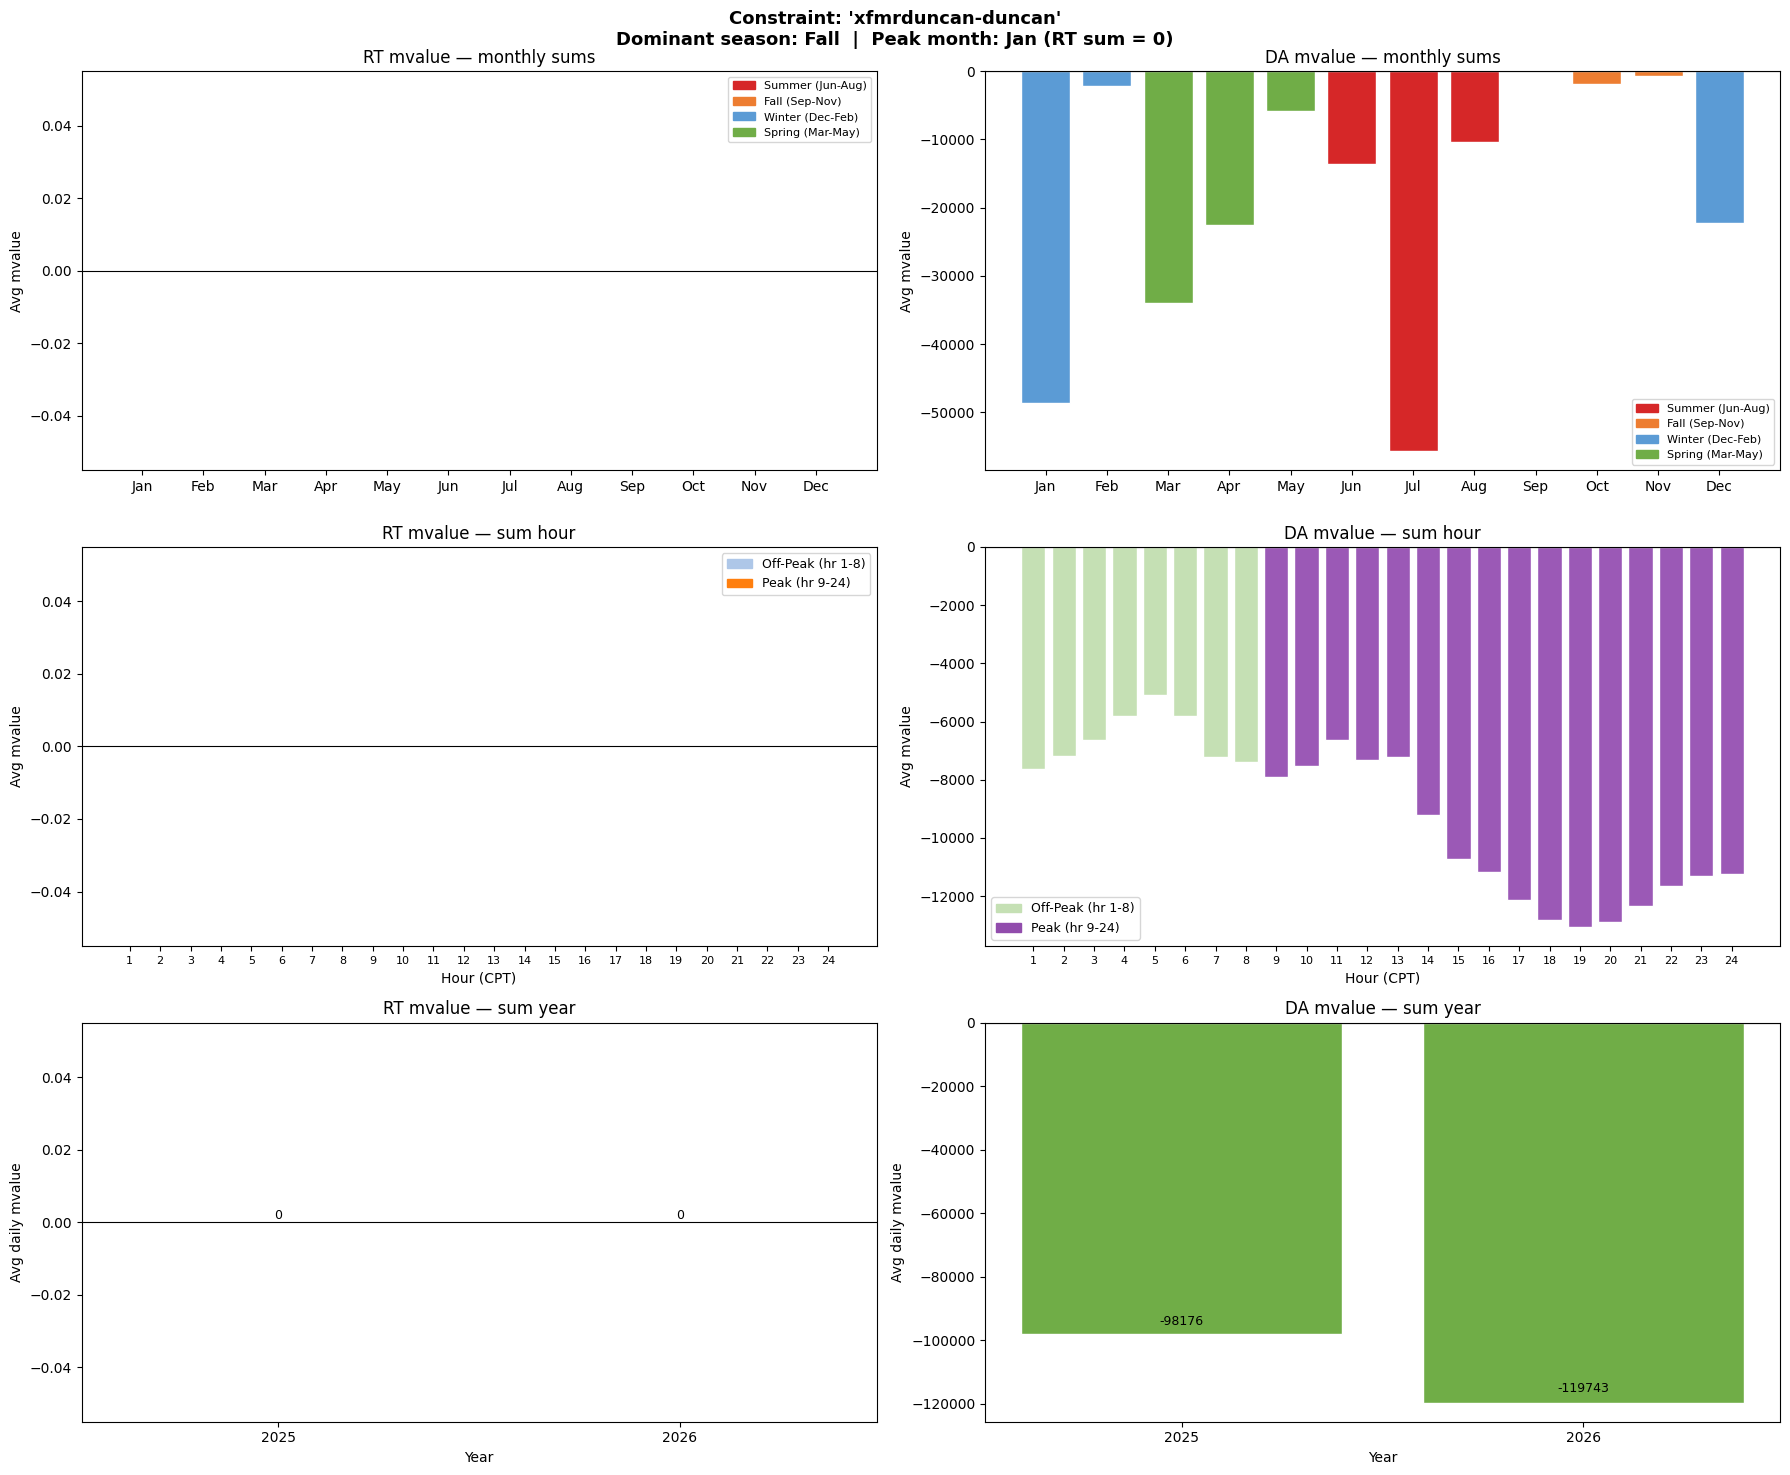

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -165135.25  |  off-peak (hr 1-8):  -52783.42
'xfmrduncan-duncan'  |  2026-05-27 → 2026-06-06  |  7 days


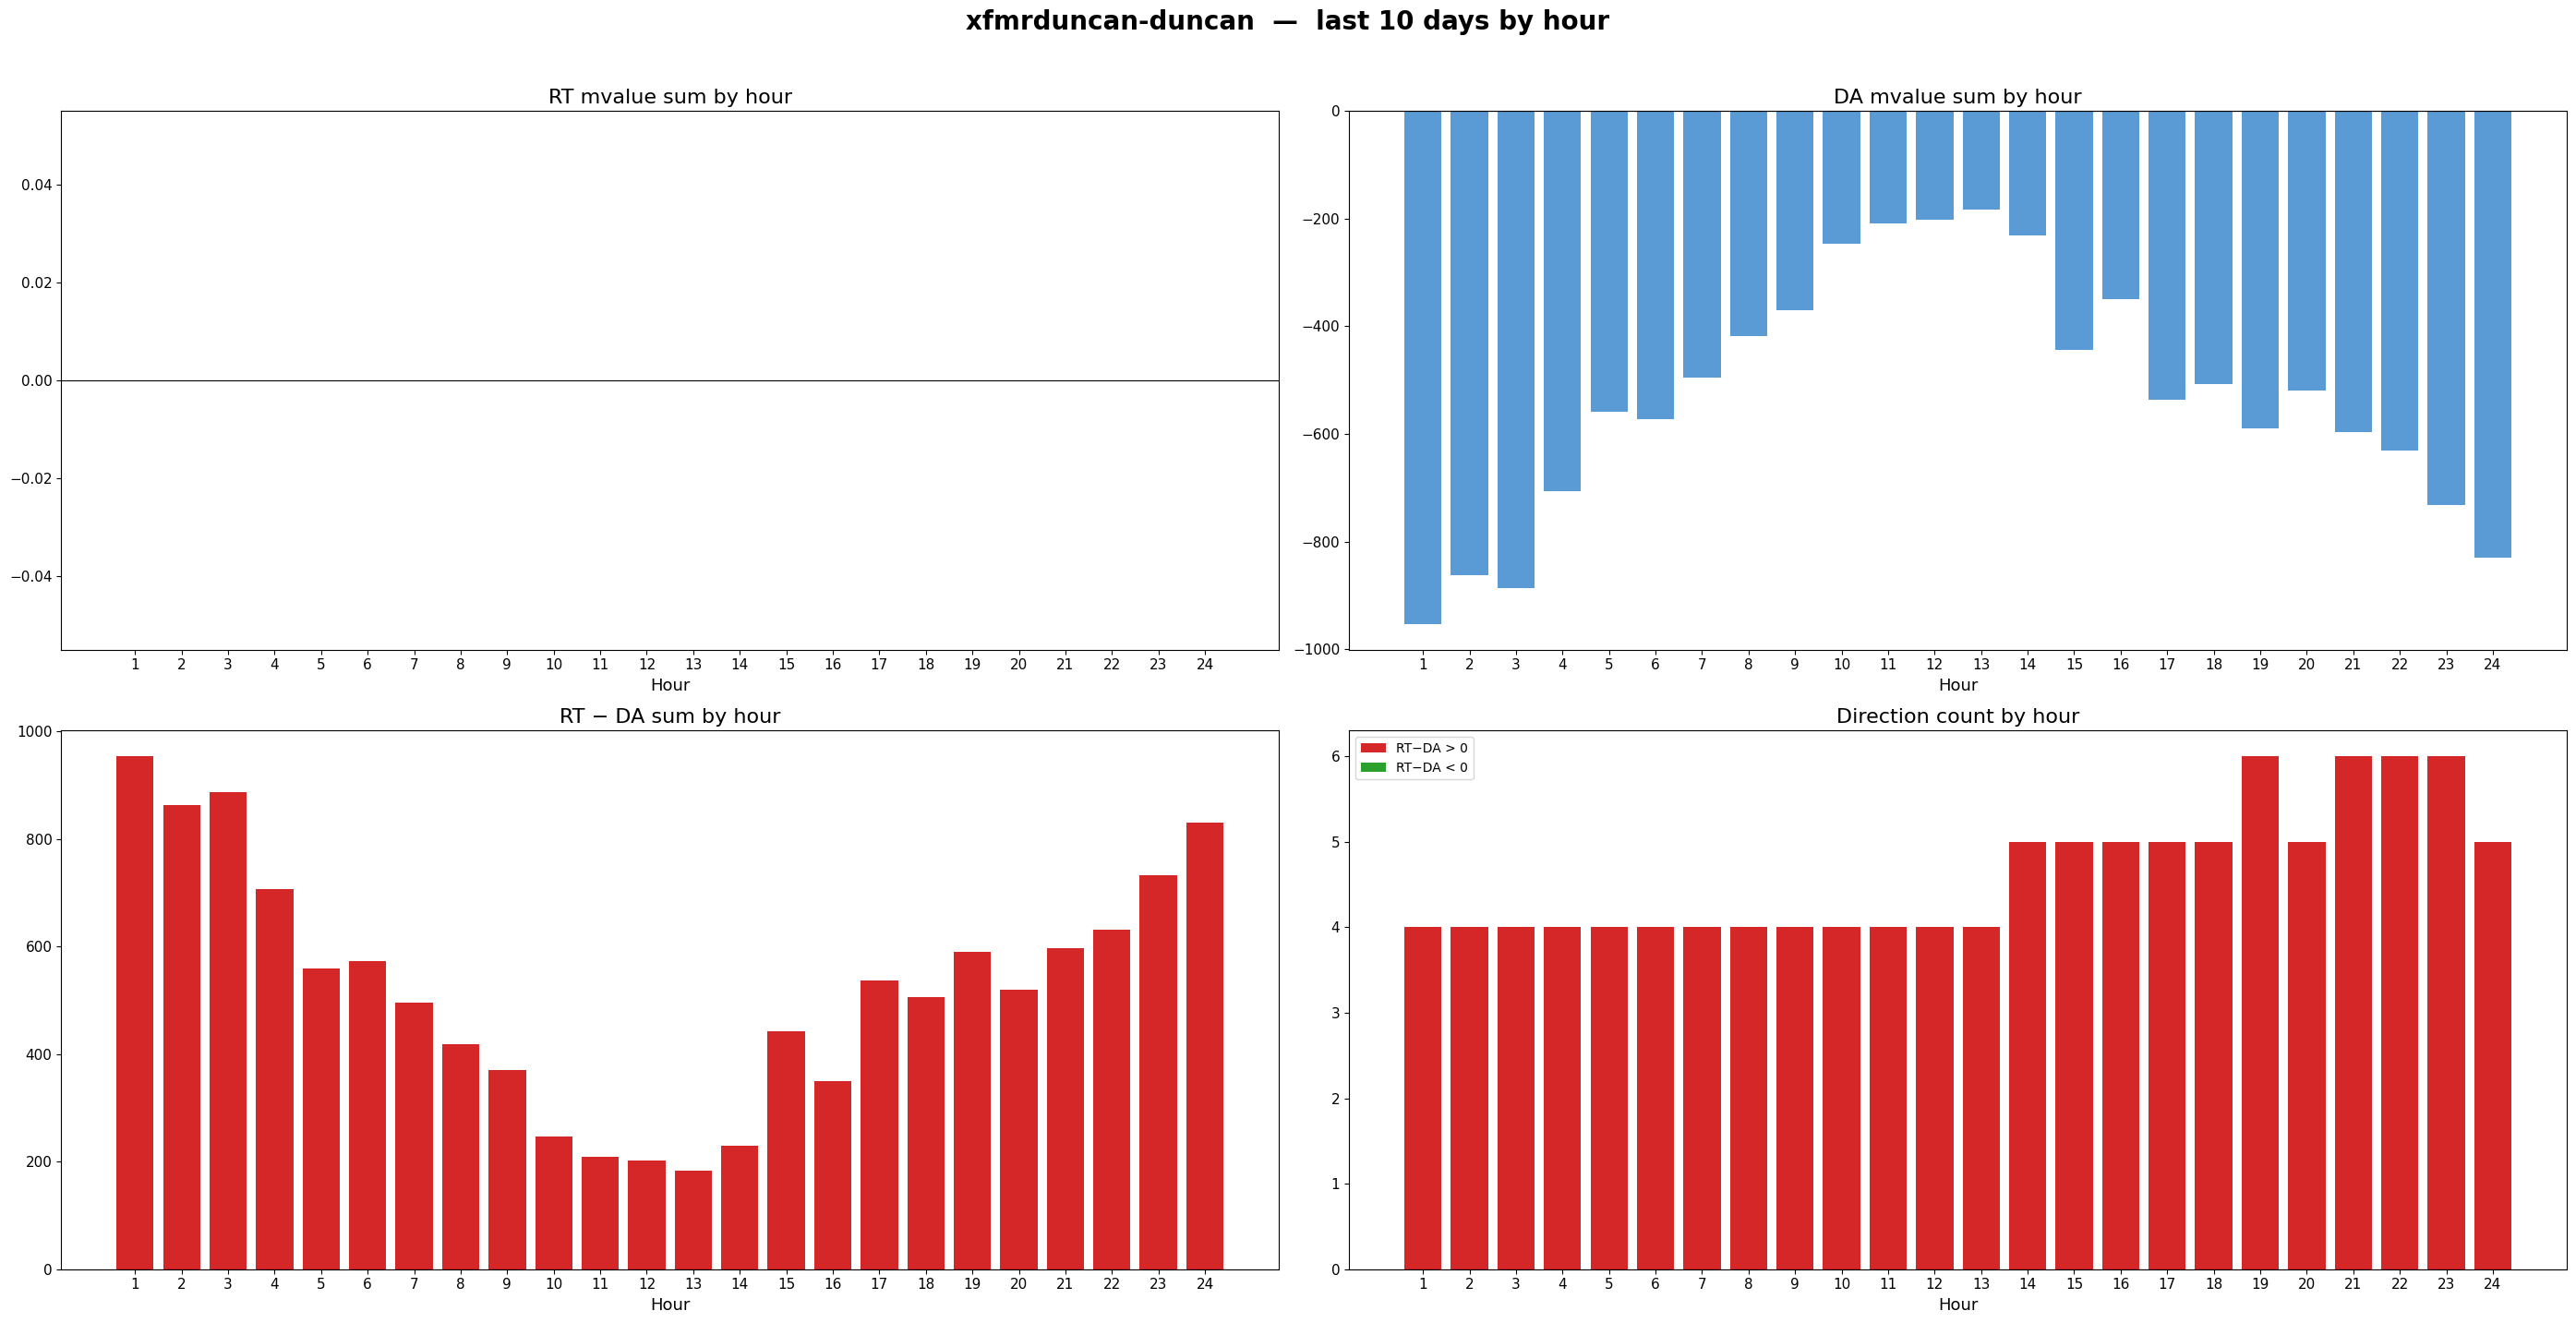


Total rows: 1988

  xfmrduncan-duncan


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1715,0.5448,0.288107,0.778816,-57.407736,-15.890162,1284.0
1,1039,-0.0611,0.094868,0.420513,11.353987,-1.298342,585.0


In [10]:
from IPython.display import display, HTML
row_counts = hourly_mvalue.groupby('monitored').size().sort_values()
print(row_counts.to_string())

for name in row_counts.index:
    display(HTML(f'''
    <hr style="border: 3px solid black; margin: 30px 0;">
    <h1 style="background:#2c3e50; color:white; padding:12px 20px; border-radius:6px; font-family:monospace;">
        {name} &nbsp;<span style="font-size:0.6em; color:#aaa;">({row_counts[name]:,} rows)</span>
    </h1>
    <hr style="border: 1px solid #aaa; margin-bottom: 20px;">
    '''))

    analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, 4, 95)
    plot_constraint_seasonality(hourly_mvalue, name)
    plot_recent_hourly_distribution(hourly_mvalue, name, bid_dt, days=10)
    table = get_constraints_node_price(hourly_mvalue, dfax, [name])
    get_metrics_for_nodes(table)

In [11]:
# name = 'lnraun-tekamho'
# zone= 1
# analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, zone, 90)
# plot_constraint_seasonality(hourly_mvalue, name)
# table = get_constraints_node_price(hourly_mvalue, dfax, [name])
# get_metrics_for_nodes(table)

In [12]:
fundamentals = get_weather_date(hourly_mvalue, bid_dt)

Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


In [13]:
tomorrow_pct = predict_tomorrow_percentile(fundamentals, bid_dt)


--- Zone 1 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,1426.4,51.6,4363.1,96.8
1,2,1322.3,51.6,4207.0,96.8
2,3,1163.6,48.4,4130.0,96.8
3,4,1011.2,45.2,4090.0,96.8
4,5,897.4,35.5,4113.4,96.8
5,6,798.5,38.7,4255.5,96.8
6,7,718.7,38.7,4521.5,100.0
7,8,558.4,38.7,4835.1,100.0
8,9,379.8,29.0,5058.0,100.0
9,10,320.0,29.0,5183.2,100.0



--- Zone 2 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,5315.0,74.2,729.0,96.8
1,2,5172.1,77.4,707.0,100.0
2,3,4941.1,74.2,676.4,100.0
3,4,4738.0,71.0,686.3,100.0
4,5,4419.4,71.0,698.1,100.0
5,6,3871.6,64.5,712.0,100.0
6,7,3327.2,58.1,738.3,100.0
7,8,2759.4,54.8,748.4,100.0
8,9,2042.6,45.2,787.7,100.0
9,10,1541.4,32.3,843.6,100.0



--- Zone 3 ---


...


--- Zone 5 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,3162.2,87.1,3828.8,100.0
1,2,3066.7,83.9,3664.9,96.8
2,3,2999.6,87.1,3573.4,74.2
3,4,2861.5,77.4,3510.2,35.5
4,5,2686.8,77.4,3524.1,45.2
5,6,2471.4,74.2,3605.3,45.2
6,7,2073.2,58.1,3749.4,64.5
7,8,1743.0,35.5,3901.1,77.4
8,9,1546.2,35.5,4041.9,100.0
9,10,1391.3,35.5,4113.6,100.0



--- Zone 21 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,721.7,74.2,2862.8,74.2
1,2,640.9,41.9,2707.8,74.2
2,3,589.4,38.7,2584.0,64.5
3,4,499.4,32.3,2514.1,61.3
4,5,421.5,19.4,2472.4,58.1
5,6,413.2,22.6,2477.5,48.4
6,7,396.4,19.4,2518.9,41.9
7,8,411.9,29.0,2605.4,45.2
8,9,428.0,32.3,2715.2,45.2
9,10,402.2,35.5,2827.5,77.4



--- Summary (median pct by zone / peak) ---
1: ow: 14, fw: 41, ol: 100, fl: 96
2: ow: 27, fw: 71, ol: 100, fl: 100
3: ow: 69, fw: 93, ol: 100, fl: 100
4: ow: 80, fw: 71, ol: 96, fl: 98
5: ow: 17, fw: 77, ol: 96, fl: 69
21: ow: 33, fw: 35, ol: 90, fl: 62
